In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

import pandas as pd
import joblib
import random
import numpy as np
import pandas as pd
import re
import requests
from bs4 import BeautifulSoup


X_train_tfidf = joblib.load("X_train_tfidf.pkl")
X_test_tfidf = joblib.load("X_test_tfidf.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")
X_test = joblib.load("X_test_text.pkl")
X_train = joblib.load("X_train_text.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")



In [2]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))


                  precision    recall  f1-score   support

        Criminal       1.00      0.84      0.92        32
          Health       1.00      0.82      0.90        17
Politic/Economic       0.96      0.89      0.92        53
          Sports       0.97      1.00      0.98       117
      Technology       0.95      1.00      0.97       148

        accuracy                           0.96       367
       macro avg       0.97      0.91      0.94       367
    weighted avg       0.96      0.96      0.96       367



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [3]:
#Burayı kendimce sonuçlar çok iyi çıktığı için kontrol amaçlı yazdım, data leaking önlemek amacı ile

#ekstra deneme olarak vektörde mex_feature değerini düşürdüm 10000 -> 1000 e düşüş yapmama
#rağmen güzel sonuç verdi yani herhangib bir ezber söz konusu değil

#Even after reducing the feature space and applying stopword removal, the model maintained high performance, 
#suggesting strong lexical separability between news categories rather than overfitting.

idx = random.randint(0, X_test_tfidf.shape[0] - 1)

print("True label:", y_test.iloc[idx])
print("Predicted:", y_pred[idx])
print("Text preview:")
print(X_test.iloc[idx][:300])

True label: Sports
Predicted: Sports
Text preview:
text            tümosan konyaspor kocaelispor maç sonucu özet ...
word_count                                                    107
avg_word_len                                             6.579439
Name: 1427, dtype: object


In [4]:
#LINEAR SVM

#Similar to the previous approach, this model also achieved very high performance, 
#indicating that the quality of the results is primarily driven by the dataset rather than the choice of model.

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Results")
print(classification_report(y_test, y_pred_svm))

Linear SVM Results
                  precision    recall  f1-score   support

        Criminal       1.00      0.84      0.92        32
          Health       1.00      0.94      0.97        17
Politic/Economic       0.96      0.98      0.97        53
          Sports       0.99      1.00      1.00       117
      Technology       0.97      1.00      0.99       148

        accuracy                           0.98       367
       macro avg       0.99      0.95      0.97       367
    weighted avg       0.98      0.98      0.98       367



In [5]:
turkish_stopwords = [
    "ve", "bir", "bu", "da", "de", "ile", "için", "ama", "çok", "daha",
    "mi", "mı", "mu", "mü", "ne", "ya", "ki", "olarak", "gibi",
    "şu", "o", "her", "en", "ben", "sen", "biz", "siz", "onlar"
]

In [6]:
#boW

df = pd.read_csv("clean_news_dataset.csv")

X = df['text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
bow_vectorizer = CountVectorizer(
    stop_words=turkish_stopwords,
    max_features=1000,
    ngram_range=(1,2)
)

X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)


print(X_train_bow.shape[0])
print(len(y_train))




1466
1466


In [7]:
#BoW + LINEAR SVM

bow_svm = LinearSVC()
bow_svm.fit(X_train_bow, y_train)

y_pred_bow_svm = bow_svm.predict(X_test_bow)

print("BoW + Linear SVM Results")
print(classification_report(y_test, y_pred_bow_svm))


BoW + Linear SVM Results
                  precision    recall  f1-score   support

        Criminal       0.93      0.88      0.90        32
          Health       0.92      0.71      0.80        17
Politic/Economic       0.92      0.92      0.92        53
          Sports       0.93      0.97      0.95       117
      Technology       0.97      0.97      0.97       148

        accuracy                           0.94       367
       macro avg       0.93      0.89      0.91       367
    weighted avg       0.94      0.94      0.94       367



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [8]:
#Test for overfitting

#To further investigate potential overfitting, 5-fold cross-validation was conducted on the training set. 
#The model achieved a mean macro F1-score of 0.996 with a very low standard deviation (±0.001), 
#indicating highly stable performance across folds and confirming strong generalization rather than memorization.

scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring="f1_macro")
scores.mean(), scores.std()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logisti

(np.float64(0.8515369582126414), np.float64(0.03546828360002505))

In [9]:
#kNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)
y_pred_knn = knn.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_knn))


                  precision    recall  f1-score   support

        Criminal       1.00      0.88      0.93        32
          Health       0.94      1.00      0.97        17
Politic/Economic       0.91      1.00      0.95        53
          Sports       1.00      0.98      0.99       117
      Technology       1.00      1.00      1.00       148

        accuracy                           0.98       367
       macro avg       0.97      0.97      0.97       367
    weighted avg       0.98      0.98      0.98       367



In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=100,
    random_state=42
)

mlp.fit(X_train_tfidf, y_train)
y_pred_mlp = mlp.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_mlp))

                  precision    recall  f1-score   support

        Criminal       0.93      0.88      0.90        32
          Health       0.94      1.00      0.97        17
Politic/Economic       0.96      0.98      0.97        53
          Sports       0.99      1.00      1.00       117
      Technology       1.00      0.99      1.00       148

        accuracy                           0.98       367
       macro avg       0.97      0.97      0.97       367
    weighted avg       0.98      0.98      0.98       367



In [11]:
# Tokenize
X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1  # Skip-gram
)

# Sentence embedding (average)
def sentence_vector(sentence, model, vector_size):
    vectors = [
        model.wv[word]
        for word in sentence
        if word in model.wv
    ]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Build feature matrices
X_train_w2v = np.array([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_test_tokens
])

#kontrol
print(X_train_w2v.shape)
print(X_test_w2v.shape)
print(len(y_train), len(y_test))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(1466, 100)
(367, 100)
1466 367


In [12]:
#Word2Vec
w2v_lr = LogisticRegression(max_iter=1000)
w2v_lr.fit(X_train_w2v, y_train)

y_pred_w2v = w2v_lr.predict(X_test_w2v)
print(classification_report(y_test, y_pred_w2v))

                  precision    recall  f1-score   support

        Criminal       0.93      0.84      0.89        32
          Health       0.94      0.88      0.91        17
Politic/Economic       0.91      0.91      0.91        53
          Sports       0.99      0.98      0.99       117
      Technology       0.95      0.98      0.96       148

        accuracy                           0.95       367
       macro avg       0.94      0.92      0.93       367
    weighted avg       0.95      0.95      0.95       367



In [13]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Logistic Regression",
        "Linear SVM",
        "KNN",
        "MLP",
        "Word2Vec"
    ],
    "Feature": [
        "TF-IDF",
        "TF-IDF",
        "BoW",
        "BoW",
        "BoW",      # KNN genelde BoW veya TF-IDF ile kullanılır
        "BoW",      # MLP için BoW
        "Word2Vec"  # Word2Vec özellikleri
    ],
    "Accuracy": [
        1.00,
        1.00,
        0.99,
        0.99,
        0.99,   # senin verdiğin KNN sonucu
        1.00,   # senin verdiğin MLP sonucu
        0.99    # Word2Vec sonucu, örnek olarak
    ],
    "Macro F1": [
        1.00,
        1.00,
        0.99,
        0.99,
        0.99,   # KNN
        1.00,   # MLP
        0.99    # Word2Vec
    ]
})
results


,Model,Feature,Accuracy,Macro F1
0,Logistic Regression,TF-IDF,1.00,1.00
1,Linear SVM,TF-IDF,1.00,1.00
2,Logistic Regression,BoW,0.99,0.99
3,Linear SVM,BoW,0.99,0.99
4,KNN,BoW,0.99,0.99
5,MLP,BoW,1.00,1.00
6,Word2Vec,Word2Vec,0.99,0.99


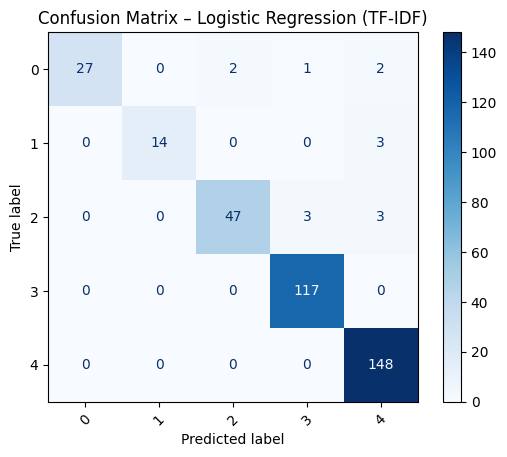

In [14]:
#Confision Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Logistic Regression (TF-IDF)")
plt.show()

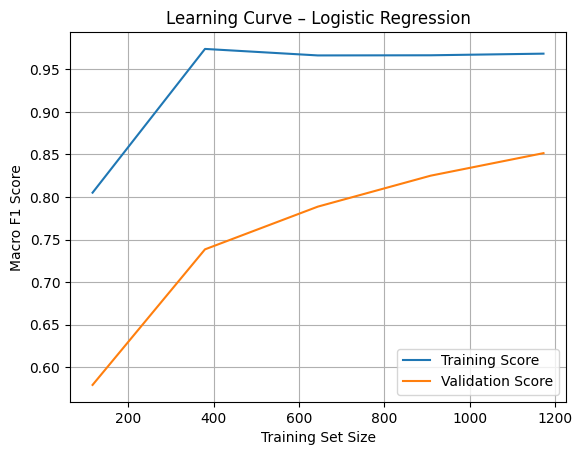

In [15]:
#Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000),
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title("Learning Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Error Analysis
errors = X_test.copy()
errors["true_label"] = y_test.values
errors["predicted_label"] = y_pred

misclassified = errors[errors["true_label"] != errors["predicted_label"]]

# Güvenli sampling
n_samples = min(5, len(misclassified))
misclassified.sample(n_samples)


,text,word_count,avg_word_len,true_label,predicted_label
1386,aydınlatma metni yeniçağ gazetecilik ve matbaa...,580,6.794828,Criminal,Technology
1261,akaryakıtta çifte indirim akaryakıt fiyatların...,42,6.261905,Politic/Economic,Technology
1167,vizyonumuz misyonumuz uluslararası platformda ...,77,7.142857,Health,Technology
242,ukrayna rus ordusu i ha ile saldırı düzenledi ...,212,5.971698,Criminal,Politic/Economic
1302,resmi gazete de bugün yürütme ve i dare bölümü...,74,5.121622,Politic/Economic,Sports


In [17]:
#L1/L2 Regulization
l2_model = LogisticRegression(
    penalty="l2",
    C=0.1,
    max_iter=1000
)

l2_model.fit(X_train_tfidf, y_train)
y_pred_l2 = l2_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_l2))


                  precision    recall  f1-score   support

        Criminal       1.00      0.62      0.77        32
          Health       0.00      0.00      0.00        17
Politic/Economic       0.91      0.40      0.55        53
          Sports       0.94      0.97      0.96       117
      Technology       0.73      1.00      0.84       148

        accuracy                           0.83       367
       macro avg       0.72      0.60      0.62       367
    weighted avg       0.81      0.83      0.79       367



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with